# Notebook 02: Temporal evolution of observed and synthetic BTs

## Imports

In [1]:
import warnings
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from goes2go import GOES

warnings.filterwarnings("ignore")

In [2]:
out_dir = "./plots/"

## Get and prepare data

In [3]:
# ICON grid
grid = xr.open_dataset(
    "./data/grids/hra_DOM01.nc",
    engine="netcdf4"
)

lon = np.rad2deg(grid.clon)
lat = np.rad2deg(grid.clat)

# Crop extent
lon_min, lon_max = lon.min().item() - 5, lon.max().item() + 5
lat_min, lat_max = lat.min().item() - 5, lat.max().item() + 5 

### Optional: Crop and prepare raw GOES-data and save as new file
* This step takes time!

In [4]:
# Set to True to download/process GOES data from scratch
process_data_from_scratch = False

In [5]:
if process_data_from_scratch:
    save_dir = Path("~/data").expanduser()

    G = GOES(satellite=18, product="ABI-L2-CMIPF", domain="F", bands=13)
    ds_range = G.timerange(
        start="2025-05-30 12:00",
        end="2025-05-30 18:00"
    )
else:
    print("Skipping data processing.")

Skipping data processing.


In [6]:
if process_data_from_scratch:
    datasets = []

    for _, row in ds_range.iterrows():
        ds = xr.open_dataset(save_dir / row["file"]).metpy.parse_cf()
        datasets.append(ds["CMI"].metpy.assign_latitude_longitude())

    ds_goes = xr.concat(datasets, dim="t")

    ds_goes = ds_goes.where(
        (ds_goes.longitude >= lon_min) & (ds_goes.longitude <= lon_max) &
        (ds_goes.latitude >= lat_min) & (ds_goes.latitude <= lat_max),
        drop=True
    )

In [7]:
if process_data_from_scratch:
    ds_goes.drop_vars("metpy_crs").to_netcdf("./goes_cropped_30e.nc")
    ds_goes.close()

### Continue with data preperation

In [8]:
# GOES brightness temperature
ds_goes = xr.open_mfdataset("./data/goes/goes_cropped_*.nc")

In [9]:
# Evaluation points
lon_fire = [-113.8]
lat_fire = [56.9]

lon_away = [-113.8]
lat_away = [53.9]

radius = 1  # degrees

In [10]:
# Define evaluation area

glon = ds_goes.longitude.values
glat = ds_goes.latitude.values

glon_flat = glon.ravel()
glat_flat = glat.ravel()

dlon = glon_flat[:, None] - lon_fire
dlat = glat_flat[:, None] - lat_fire
distance = np.sqrt(dlon**2 + dlat**2)

mask_flat = (distance <= radius).any(axis=1)
mask_2d = mask_flat.reshape(glon.shape)

In [11]:
dlon = glon_flat[:, None] - lon_away
dlat = glat_flat[:, None] - lat_away
distance_away = np.sqrt(dlon**2 + dlat**2)

mask_flat_away = (distance_away <= radius).any(axis=1)
mask_2d_away = mask_flat_away.reshape(glon.shape)

In [12]:
# Get some coordinate informations
grid = xr.open_dataset("./data/grids/hra_DOM01.nc")
lon_icon = np.rad2deg(grid.clon.values)
lat_icon = np.rad2deg(grid.clat.values)


In [13]:
# ICON grid masks

mask_fire = np.sqrt(
    (lon_icon - lon_fire) ** 2 +
    (lat_icon - lat_fire) ** 2
) <= radius

mask_away = np.sqrt(
    (lon_icon - lon_away) ** 2 +
    (lat_icon - lat_away) ** 2
) <= radius

In [14]:
synpath = "/work/bb1174/user/jason/hra_data/synsat/"
filetype = "lam_hra_2025_synsat*"

In [15]:
# Synthetic satellite brightness temperatures
synpath = "/work/bb1174/user/jason/hra_data/synsat/"
exp_ids = ["25", "27", "31", "23", "28", "29"]

syns = [
    xr.open_mfdataset(f"{synpath}ABI-exp{exp}/{filetype}")
    .bt112.isel(ncells=mask_fire)
    for exp in exp_ids
]

syns_away = [
    xr.open_mfdataset(f"{synpath}ABI-exp{exp}/{filetype}")
    .bt112.isel(ncells=mask_away)
    for exp in exp_ids
]

## Plot data

In [16]:
# Plot settings
lw = 3
fsize = 25

pyrocb_start = np.datetime64("2025-05-30T01:00:00")
pyrocb_end = np.datetime64("2025-05-30T04:00:00")
modis_time = np.datetime64("2025-05-30T03:30:00")

time_start = np.datetime64("2025-05-29T12:00:00")
time_end = np.datetime64("2025-05-30T18:00:00")

bt_min, bt_max = 205, 305
height_max = 13.5

names = ["E0", "E10", "E30", "E50", "E70", "E70*"]

colors = [
    "#719ecd", "#65c15b", "#f7ba0b",
    "#ff9c4b", "#ee665c", "#ac8bca"
]

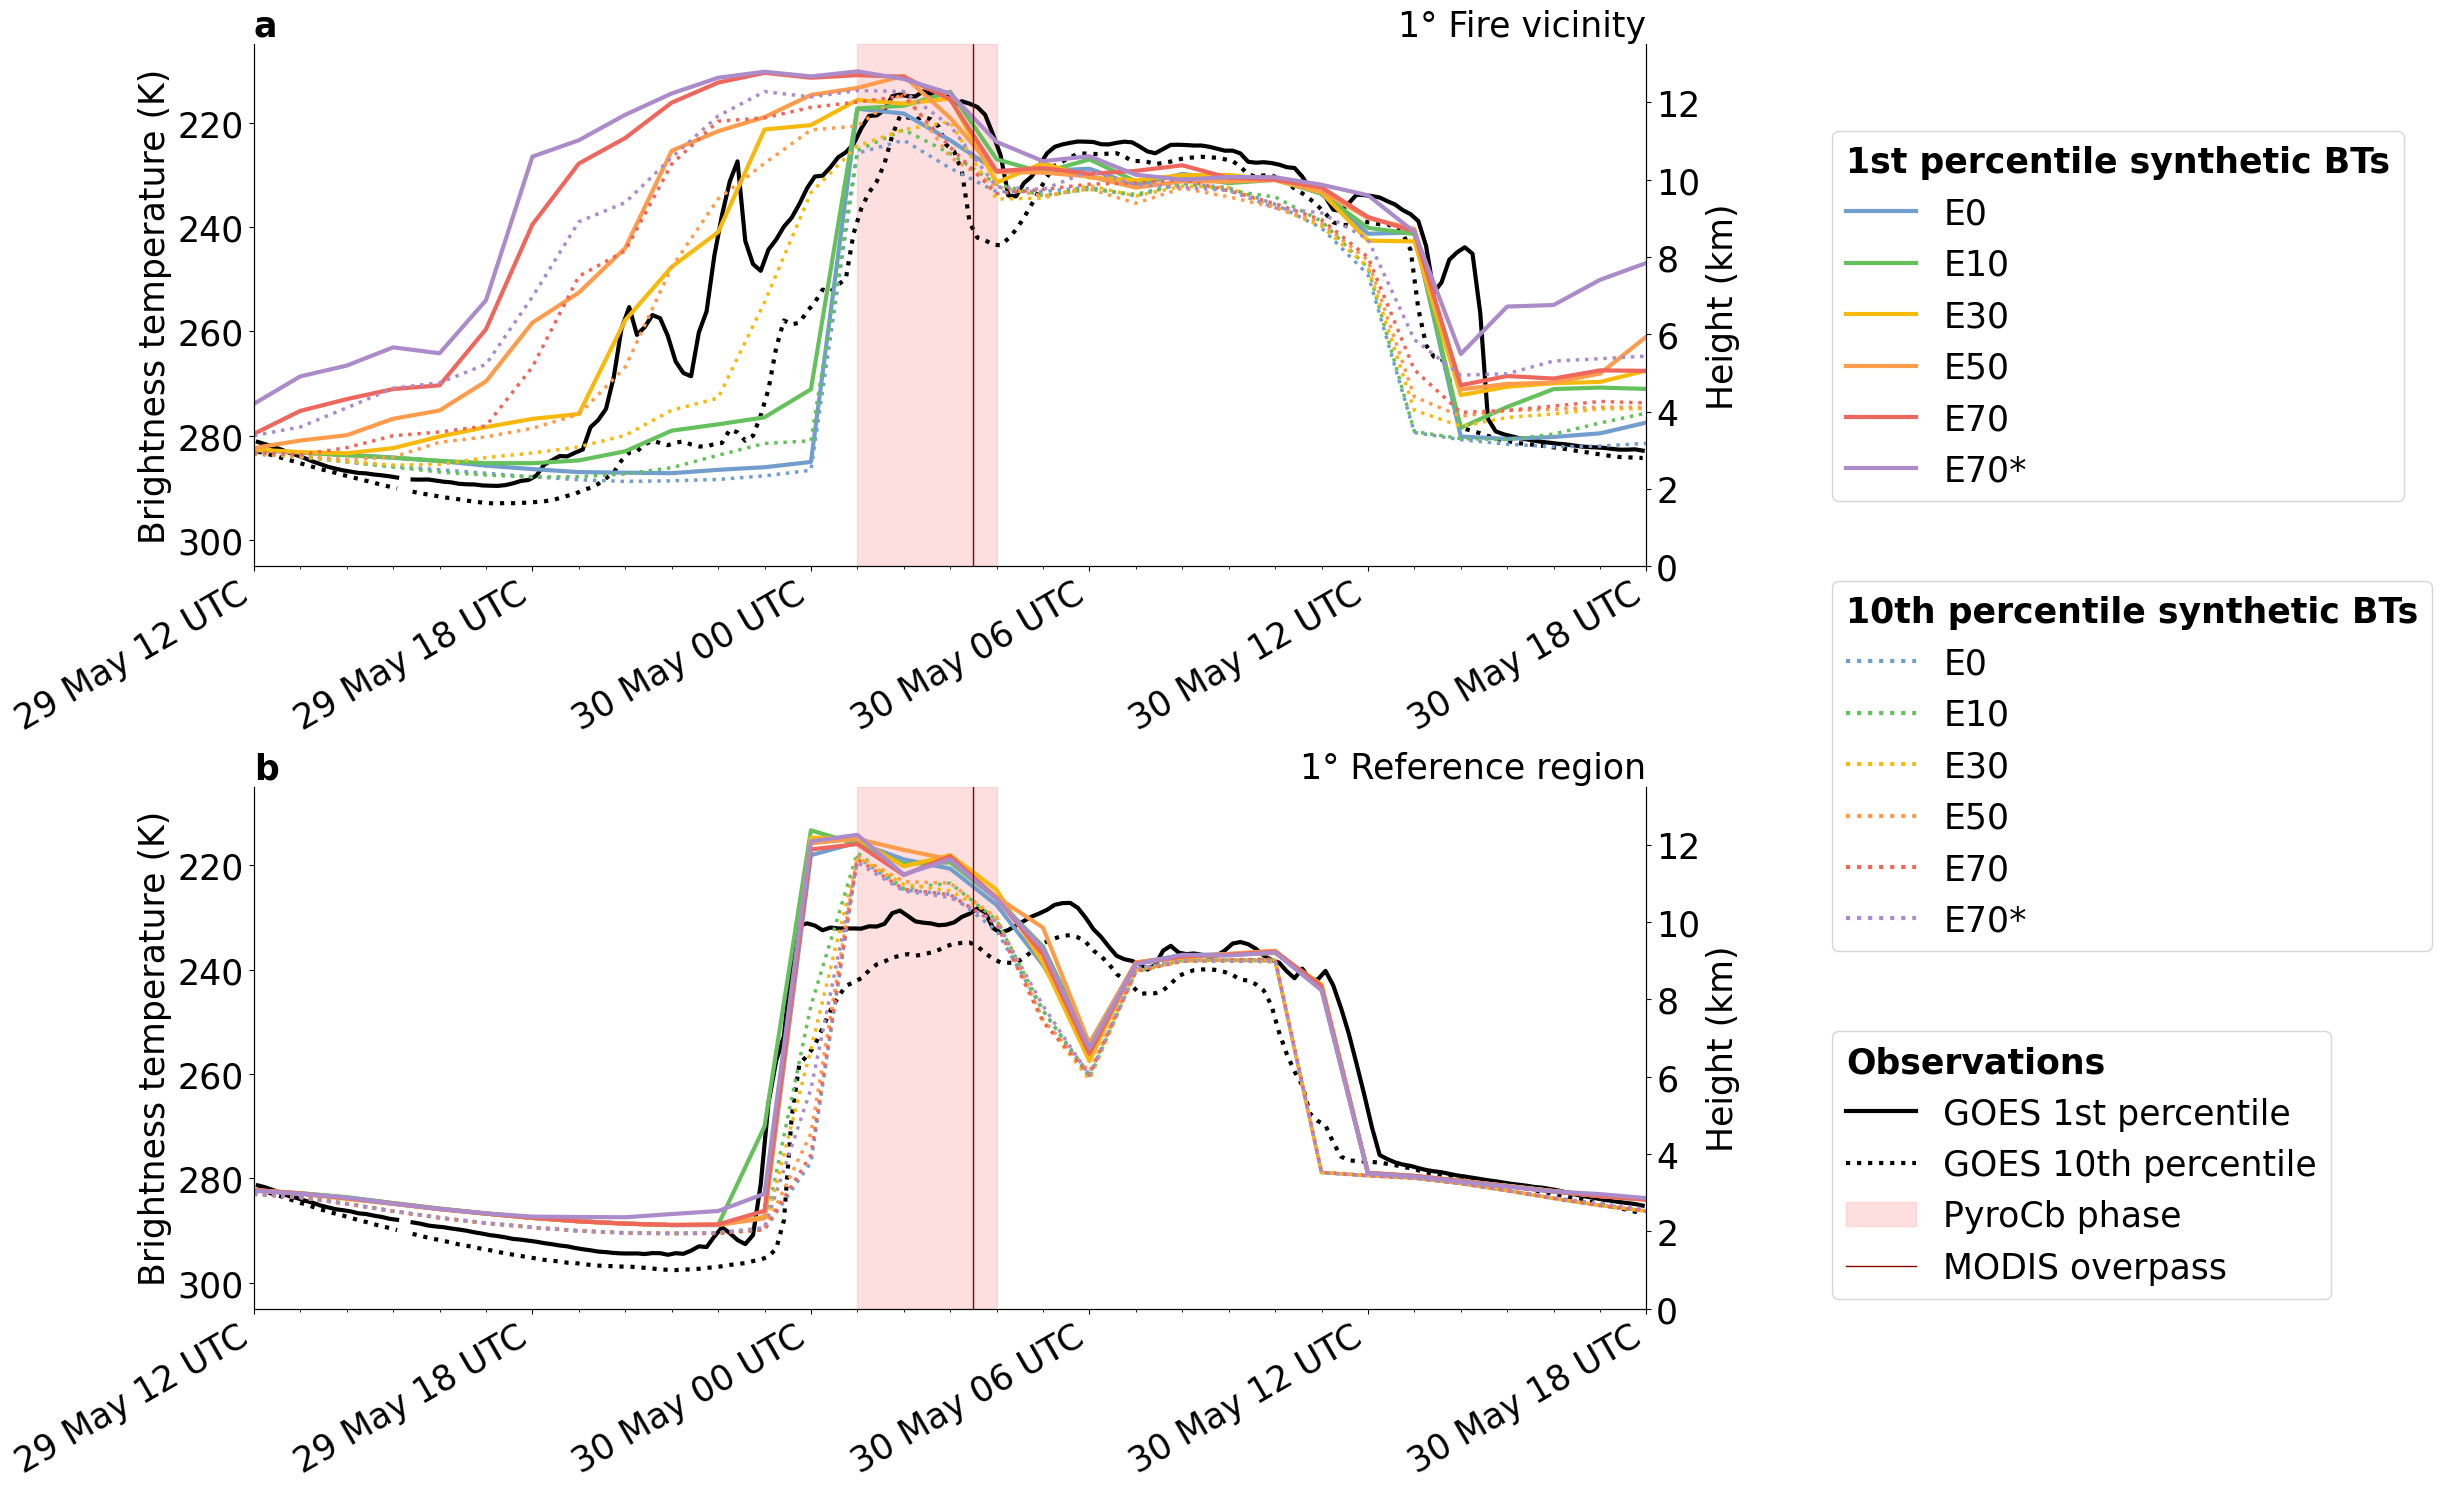

In [17]:
# -------------------------------------------------
# Figure
# -------------------------------------------------
fig, axes = plt.subplots(
    2, 1,
    figsize=(20, 15),
    sharey=True
)


def plot_panel(ax, mask, syns, title, label):

    # -------------------------------------------------
    # Observed PyroCb period
    # -------------------------------------------------
    ax.axvspan(
        pyrocb_start, pyrocb_end,
        color="#FCA5A5",
        alpha=0.35,
        zorder=-2
    )

    # -------------------------------------------------
    # MODIS overpass
    # -------------------------------------------------
    ax.axvline(
        modis_time,
        color="darkred",
        lw=1,
        zorder=5
    )

    # -------------------------------------------------
    # GOES brightness temperature
    # -------------------------------------------------
    for q, ls in [
        (0.01, "-"),
        (0.1, ":")
    ]:
        ax.plot(
            ds_goes.t,
            ds_goes.CMI.where(mask).quantile(
                q, dim=("x", "y")
            ),
            color="black",
            linestyle=ls,
            lw=lw
        )

    # -------------------------------------------------
    # Synthetic brightness temperature
    # -------------------------------------------------
    for i, s in enumerate(syns):

        # 1st percentile
        ax.plot(
            s.time,
            s.quantile(q=0.01, dim="ncells"),
            color=colors[i],
            linestyle="-",
            lw=lw
        )

        # 10th percentile
        ax.plot(
            s.time,
            s.quantile(q=0.1, dim="ncells"),
            color=colors[i],
            linestyle=":",
            lw=2.5
        )

    # -------------------------------------------------
    # Titles
    # -------------------------------------------------
    ax.set_title(
        label,
        loc="left",
        fontsize=fsize,
        fontweight="bold"
    )

    ax.set_title(
        title,
        loc="right",
        fontsize=fsize
    )

    # -------------------------------------------------
    # Y axis
    # -------------------------------------------------
    ax.set_ylabel(
        "Brightness temperature (K)",
        fontsize=fsize
    )

    ax.set_ylim(bt_min, bt_max)
    ax.invert_yaxis()

    ax.tick_params(
        axis="both",
        labelsize=fsize
    )

    # -------------------------------------------------
    # Height axis
    # -------------------------------------------------
    ax2 = ax.twinx()

    ax2.set_ylabel(
        "Height (km)",
        fontsize=fsize
    )

    ax2.set_ylim(0, height_max)

    ax2.tick_params(
        axis="y",
        labelsize=fsize
    )

    # -------------------------------------------------
    # X axis
    # -------------------------------------------------
    ax.set_xlim(time_start, time_end)

    ax.xaxis.set_major_locator(
        mdates.HourLocator(byhour=[0, 6, 12, 18])
    )

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%d %b %H UTC")
    )

    ax.xaxis.set_minor_locator(
        mdates.HourLocator(interval=1)
    )

    plt.setp(
        ax.get_xticklabels(),
        rotation=30,
        ha="right",
        fontsize=fsize
    )

    # -------------------------------------------------
    # Spines
    # -------------------------------------------------
    ax.spines["top"].set_visible(False)
    ax2.spines["top"].set_visible(False)


# -------------------------------------------------
# Plot panels
# -------------------------------------------------
plot_panel(
    axes[0],
    mask_2d,
    syns,
    "1° Fire vicinity",
    "a"
)

plot_panel(
    axes[1],
    mask_2d_away,
    syns_away,
    "1° Reference region",
    "b"
)


# =================================================
# LEGENDS
# =================================================

# -------------------------------------------------
# 1st percentile synthetic BTs
# -------------------------------------------------
handles_1st = [
    mlines.Line2D(
        [],
        [],
        color=colors[i],
        linestyle="-",
        lw=lw,
        label=names[i]
    )
    for i in range(len(names))
]

legend_1st = fig.legend(
    handles=handles_1st,
    title="1st percentile synthetic BTs",
    loc="upper left",
    bbox_to_anchor=(0.91, 0.92),
    fontsize=fsize,
    title_fontsize=fsize,
    frameon=True,
    alignment="left"
)

legend_1st.get_title().set_fontweight("bold")


# -------------------------------------------------
# 10th percentile synthetic BTs
# -------------------------------------------------
handles_10th = [
    mlines.Line2D(
        [],
        [],
        color=colors[i],
        linestyle=":",
        lw=lw,
        label=names[i]
    )
    for i in range(len(names))
]

legend_10th = fig.legend(
    handles=handles_10th,
    title="10th percentile synthetic BTs",
    loc="upper left",
    bbox_to_anchor=(0.91, 0.62),
    fontsize=fsize,
    title_fontsize=fsize,
    frameon=True,
    alignment="left"
)

legend_10th.get_title().set_fontweight("bold")


# -------------------------------------------------
# Observations
# -------------------------------------------------
goes_p1 = mlines.Line2D(
    [],
    [],
    color="black",
    linestyle="-",
    lw=lw,
    label="GOES 1st percentile"
)

goes_p10 = mlines.Line2D(
    [],
    [],
    color="black",
    linestyle=":",
    lw=lw,
    label="GOES 10th percentile"
)

patch_handle = mpatches.Patch(
    color="#FCA5A5",
    alpha=0.35,
    label="PyroCb phase"
)

modis_handle = mlines.Line2D(
    [],
    [],
    color="darkred",
    lw=1,
    label="MODIS overpass"
)

legend_obs = fig.legend(
    handles=[
        goes_p1,
        goes_p10,
        patch_handle,
        modis_handle
    ],
    title="Observations",
    loc="upper left",
    bbox_to_anchor=(0.91, 0.32),
    fontsize=fsize,
    title_fontsize=fsize,
    frameon=True,
    alignment="left"
)

legend_obs.get_title().set_fontweight("bold")
# -------------------------------------------------
# Layout
# -------------------------------------------------
plt.tight_layout(
    rect=[0, 0, 0.88, 1]
)

plt.show()

fig.savefig(
    out_dir + "brightness_temperature_comparison.png",
    dpi=300,
    bbox_inches="tight"
)